In [ ]:
import os, sys
from pathlib import Path

# Navigate to project root (parent of notebooks/)
_cwd = Path().resolve()
PROJECT_ROOT = _cwd.parent if _cwd.name == 'notebooks' else _cwd
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import config

Path('outputs/models').mkdir(parents=True, exist_ok=True)
Path('outputs/figures').mkdir(parents=True, exist_ok=True)

print("✅ Ready.")
for f in Path('outputs').glob('raw_*.parquet'):
    print(f"  {f.name}  ({f.stat().st_size / 1024 / 1024:.1f} MB)")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

SEED = 42
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 03_2 — LSTM Model

Unlike RF/XGBoost, which rely on aggregated statistics, the LSTM model processes the raw temporal sequence within each window to capture dynamic sensor patterns.

**Data Format Comparison:**
- **RF/XGBoost:** `[n_windows, n_features]` — 2D tensor, using window-level statistics.
- **LSTM:** `[n_windows, window_size, n_sensors]` — 3D tensor, using raw time-series data.

**Input:**  `outputs/raw_train.parquet`, `outputs/raw_test.parquet`  
**Output:** `outputs/models/lstm_baseline.keras`

In [ ]:
from src.config import SENSORS, WINDOW_SIZE, WINDOW_STEP

# Exclude P-PDG as it is considered a non-functional or 'dead' sensor in this dataset
LSTM_SENSORS = [s for s in SENSORS if s != "P-PDG"]

print("Loading raw normalized data...")
df_train = pd.read_parquet("outputs/raw_train.parquet")
df_test  = pd.read_parquet("outputs/raw_test.parquet")

print(f"Train rows: {len(df_train):,}  |  Test rows: {len(df_test):,}")
print(f"Sensors used: {LSTM_SENSORS}")


def build_windows(df: pd.DataFrame, sensors: list,
                  window_size: int, step: int):
    """
    Constructs a 3D tensor [n_windows, window_size, n_sensors]
    and a label vector from normalized raw data.

    Logic:
    1. Group by 'source' to avoid mixing different events into one window.
    2. Slide a window across the time series with a defined step.
    3. If > 10% of the window contains an anomaly, the whole window is labeled as 1.
    """
    X_list, y_list = [], []

    for source, group in df.groupby("source"):
        group = group.reset_index(drop=True)
        n = len(group)

        for start in range(0, n - window_size, step):
            window = group.iloc[start: start + window_size]

            # Labeling logic: identify windows with significant anomaly presence
            anomaly_ratio = (window["label"] == 1).mean()
            label = 1 if anomaly_ratio > 0.1 else 0

            X_list.append(window[sensors].values.astype(np.float32))
            y_list.append(label)

    return np.array(X_list), np.array(y_list)

print("\nBuilding windows for train...")
X_train, y_train = build_windows(df_train, LSTM_SENSORS, WINDOW_SIZE, WINDOW_STEP)
print(f"  Shape: {X_train.shape}  |  Anomaly rate: {y_train.mean()*100:.1f}%")

print("Building windows for test...")
X_test, y_test = build_windows(df_test, LSTM_SENSORS, WINDOW_SIZE, WINDOW_STEP)
print(f"  Shape: {X_test.shape}  |  Anomaly rate: {y_test.mean()*100:.1f}%")

Loading raw normalized data...
Train rows: 19,920,727  |  Test rows: 5,169,376
Sensors used: ['T-TPT', 'P-TPT', 'P-MON-CKP', 'T-JUS-CKP']

Building windows for train...
  Shape: (662805, 60, 4)  |  Anomaly rate: 41.3%
Building windows for test...
  Shape: (172016, 60, 4)  |  Anomaly rate: 49.1%


## 1. Build LSTM Model

In [ ]:
n_timesteps = X_train.shape[1]  # Expected WINDOW_SIZE = 60
n_features  = X_train.shape[2]  # Number of sensors

# Calculate class weights to handle imbalance between Normal and Anomaly windows
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
class_weight = {0: 1.0, 1: neg / pos}
print(f"Class weights: {class_weight}")

# Baseline LSTM Architecture
model = keras.Sequential([
    layers.Input(shape=(n_timesteps, n_features)),

    # First LSTM layer captures temporal patterns; return_sequences=True passes states to next layer
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),

    # Second LSTM layer extracts high-level features for the whole sequence
    layers.LSTM(32, return_sequences=False),
    layers.Dropout(0.2),

    layers.Dense(16, activation="relu"),
    layers.Dense(1,  activation="sigmoid"),
], name="lstm_baseline")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")],
)

model.summary()

Class weights: {0: 1.0, 1: np.float64(1.420949013620475)}


Model: "lstm_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,625 (119.63 KB)

 Trainable params: 30,625 (119.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        mode="min",
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        mode="min",
        verbose=1,
    ),
]

history = model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=30,
    batch_size=1024,
    class_weight=class_weight,
    callbacks=callbacks,
    shuffle=True,
    verbose=1,
)

Epoch 1/30
551/551 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.8803 - auc: 0.9404 - loss: 0.3504 - val_accuracy: 0.6553 - val_auc: 0.9048 - val_loss: 0.8101 - learning_rate: 0.0010
Epoch 2/30
551/551 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.9005 - auc: 0.9580 - loss: 0.2888 - val_accuracy: 0.6744 - val_auc: 0.7880 - val_loss: 1.2269 - learning_rate: 0.0010
Epoch 3/30
549/551 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9099 - auc: 0.9646 - loss: 0.2633
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
551/551 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.9114 - auc: 0.9652 - loss: 0.2599 - val_accuracy: 0.6745 - val_auc: 0.8792 - val_loss: 0.9395 - learning_rate: 0.0010
Epoch 4/30
551/551 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.9215 - auc: 0.9715 - loss: 0.2339 - val_accuracy: 0.7397 - val_auc: 0.8668 - val_loss: 0.8781 - learning_rate: 5.0000e-04
Epoch 5/30
548/551 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9225 - auc: 0.9729 

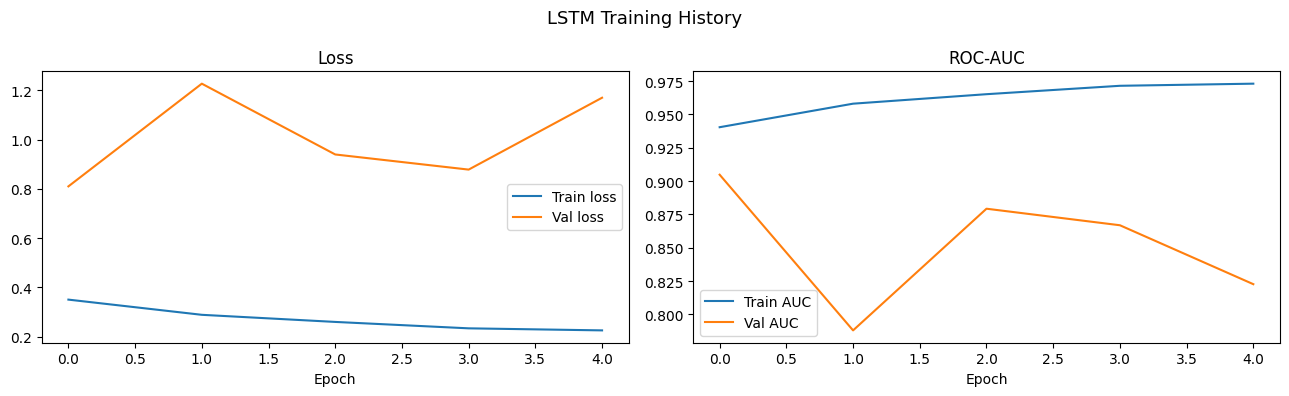

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history["loss"],     label="Train loss")
axes[0].plot(history.history["val_loss"], label="Val loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["auc"],     label="Train AUC")
axes[1].plot(history.history["val_auc"], label="Val AUC")
axes[1].set_title("ROC-AUC")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.suptitle("LSTM Training History", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/figures/lstm_training_history.png", dpi=150)
plt.show()

In [ ]:
y_proba_lstm = model.predict(X_test, batch_size=512).flatten()
y_pred_lstm  = (y_proba_lstm >= 0.5).astype(int)
roc_lstm     = roc_auc_score(y_test, y_proba_lstm)
cm_lstm      = confusion_matrix(y_test, y_pred_lstm)

print("=== LSTM Baseline Performance ===")
print(classification_report(y_test, y_pred_lstm,
                             target_names=["Normal", "Anomaly"]))
print(f"ROC-AUC : {roc_lstm:.4f}")
print(f"FN      : {cm_lstm[1,0]}  (missed anomalies)")
print(f"FP      : {cm_lstm[0,1]}  (false alarms)")

336/336 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
=== LSTM Baseline Performance ===
              precision    recall  f1-score   support

      Normal       0.86      0.84      0.85     87601
     Anomaly       0.83      0.86      0.85     84415

    accuracy                           0.85    172016
   macro avg       0.85      0.85      0.85    172016
weighted avg       0.85      0.85      0.85    172016

ROC-AUC : 0.8795
FN      : 11702  (missed anomalies)
FP      : 14397  (false alarms)


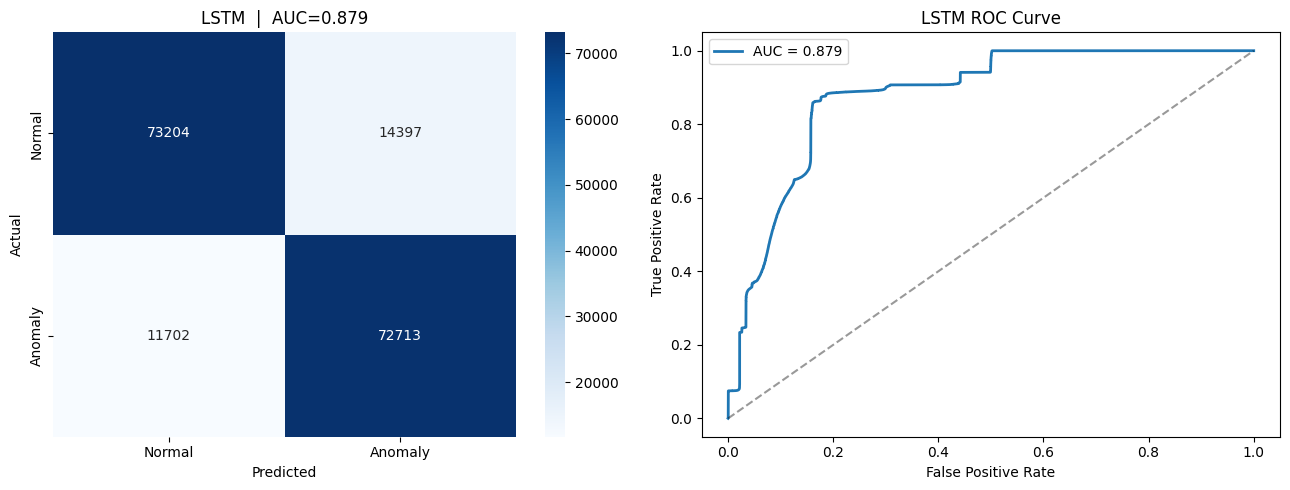

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
sns.heatmap(cm_lstm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Normal", "Anomaly"],
            yticklabels=["Normal", "Anomaly"])
axes[0].set_title(f"LSTM  |  AUC={roc_lstm:.3f}")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba_lstm)
axes[1].plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_lstm:.3f}")
axes[1].plot([0,1],[0,1],"k--", alpha=0.4)
axes[1].set_title("LSTM ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.savefig("outputs/figures/lstm_evaluation.png", dpi=150)
plt.show()

In [ ]:
model.save('outputs/models/lstm_baseline.keras')
print("✅ Model saved locally to outputs/models/lstm_baseline.keras")

✅ Model saved locally to outputs/models/lstm_baseline.keras


In [ ]:
print("✅ LSTM model saved locally.")
print(f"  outputs/models/lstm_baseline.keras")
for f in Path('outputs/figures').glob('lstm_*.png'):
    print(f"  outputs/figures/{f.name}")